In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Make dataframe with enrichment scores, p-val, and proportion from analyses
data = {
    'stats': ['odds_ratio', 'p-val', 'fraction of top 10%'],
    'oncokb': [1.494, 0.000165, (116+17)/2559],
    'clinvar': [1.245, 1.932e-80, 9352/(83183+111)],
    'tcga': [1.089, 0.141, 225/1127],
    'stringdb': [1.094, 0.263, 62/1431]
}
df_plot = pd.DataFrame(data).set_index('stats')

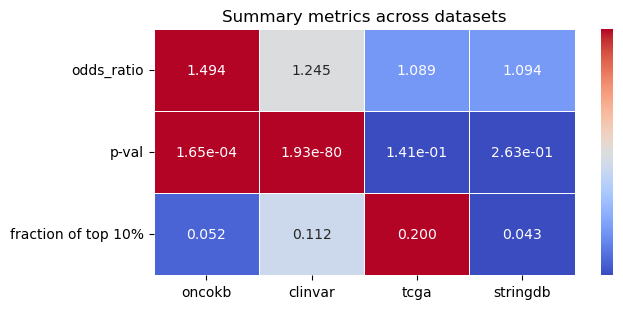

In [3]:
# Plot
# create a color matrix (same shape)
color_matrix = np.zeros_like(df_plot.values, dtype=float)

# Row 1: odds ratio (center at 1) 
odds = df_plot.loc['odds_ratio']
color_matrix[0] = (odds - 1) / (odds.max() - 1 + 1e-9)  # normalize around 1

# Row 2: p-values (binary rule) 
pvals = df_plot.loc['p-val']
color_matrix[1] = (pvals < 0.05).astype(int)  # 1 = significant

# Row 3: fraction (normal scaling)
frac = df_plot.loc['fraction of top 10%']
color_matrix[2] = (frac - frac.min()) / (frac.max() - frac.min() + 1e-9)

# annotations (nice formatting)
annot_df = df_plot.copy().astype(object)
annot_df.loc['odds_ratio'] = annot_df.loc['odds_ratio'].map(lambda x: f"{x:.3f}")
annot_df.loc['p-val'] = annot_df.loc['p-val'].map(lambda x: f"{x:.2e}")
annot_df.loc['fraction of top 10%'] = annot_df.loc['fraction of top 10%'].map(lambda x: f"{x:.3f}")

plt.figure(figsize=(7, 3.2))

sns.heatmap(
    color_matrix,
    annot=annot_df,
    fmt="",
    cmap="coolwarm",
    linewidths=0.5,
    xticklabels=df_plot.columns,
    yticklabels=df_plot.index,
    cbar=True,
    cbar_kws={"ticks": []}   # unlabeled gradient bar
)

plt.title("Summary metrics across datasets")
plt.tight_layout()
plt.show()